# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** [Input Nama]
- **Email:** [Input Email]
- **ID Dicoding:** [Input Username]

## Import Semua Packages/Library yang Digunakan

In [2]:
!pip install -q tensorflowjs
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [35]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import subprocess
from google.colab import files


In [4]:
# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Mengimpor libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [27]:
# Mengimpor libraries untuk pembuatan dan evaluasi model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
import tensorflowjs as tfjs


## Data Preparation

### Data Loading

In [41]:
zip_path = '/content/dataset_cat_dog.zip'
extract_dir = '/content/dataset'

# Ekstrak zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset berhasil diekstrak ke:", extract_dir)
print("Isi folder dataset:", os.listdir(extract_dir))

Dataset berhasil diekstrak ke: /content/dataset
Isi folder dataset: ['Train', 'Val', 'Test']


In [9]:
def create_validation_split(test_dir, val_dir, split_ratio=0.2):
    os.makedirs(val_dir, exist_ok=True)
    for category in os.listdir(test_dir):
        test_cat_dir = os.path.join(test_dir, category)
        val_cat_dir = os.path.join(val_dir, category)
        os.makedirs(val_cat_dir, exist_ok=True)

        files = os.listdir(test_cat_dir)
        random.shuffle(files)
        n_val = int(len(files) * split_ratio)
        val_files = files[:n_val]

        for f in val_files:
            shutil.move(os.path.join(test_cat_dir, f),
                        os.path.join(val_cat_dir, f))

### Data Preprocessing

#### Split Dataset

In [11]:
val_dir = "/content/dataset/Val"
test_dir = "/content/dataset/Test"

create_validation_split(test_dir, val_dir, split_ratio=0.2)
train_dir = '/content/dataset/Train'

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)

Found 23650 images belonging to 2 classes.
Found 1389 images belonging to 2 classes.
Found 2474 images belonging to 2 classes.


## Modelling

In [15]:
# Transfer learning backbone
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150,150,3))
base_model.trainable = False  # Freeze base model

# Bangun Sequential model
model = Sequential([
    base_model,
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/tmp/ipython-input-3679684915.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150,150,3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,013,825 (11.50 MB)

 Trainable params: 755,841 (2.88 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
]
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)
loss, acc = model.evaluate(test_generator)
print(f"\n Akurasi pada data test: {acc * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9119 - loss: 0.2651

370/370 ━━━━━━━━━━━━━━━━━━━━ 195s 472ms/step - accuracy: 0.9119 - loss: 0.2649 - val_accuracy: 0.9690 - val_loss: 0.0898
Epoch 2/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 147s 398ms/step - accuracy: 0.9499 - loss: 0.1198 - val_accuracy: 0.9633 - val_loss: 0.0983
Epoch 3/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 150s 406ms/step - accuracy: 0.9518 - loss: 0.1205 - val_accuracy: 0.9676 - val_loss: 0.0807
Epoch 4/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9577 - loss: 0.1063

370/370 ━━━━━━━━━━━━━━━━━━━━ 148s 400ms/step - accuracy: 0.9577 - loss: 0.1064 - val_accuracy: 0.9698 - val_loss: 0.0769
Epoch 5/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9582 - loss: 0.1062

370/370 ━━━━━━━━━━━━━━━━━━━━ 150s 405ms/step - accuracy: 0.9582 - loss: 0.1062 - val_accuracy: 0.9726 - val_loss: 0.0759
Epoch 6/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 152s 411ms/step - accuracy: 0.9591 - loss: 0.1019 - val_accuracy: 0.9698 - val_loss: 0.0752
Epoch 7/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 150s 405ms/step - accuracy: 0.9600 - loss: 0.1007 - val_accuracy: 0.9712 - val_loss: 0.0761
Epoch 8/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9648 - loss: 0.0885

370/370 ━━━━━━━━━━━━━━━━━━━━ 148s 401ms/step - accuracy: 0.9647 - loss: 0.0885 - val_accuracy: 0.9741 - val_loss: 0.0666
Epoch 9/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 148s 399ms/step - accuracy: 0.9647 - loss: 0.0940 - val_accuracy: 0.9741 - val_loss: 0.0695
Epoch 10/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 203s 404ms/step - accuracy: 0.9626 - loss: 0.0909 - val_accuracy: 0.9726 - val_loss: 0.0683
Epoch 11/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9643 - loss: 0.0866

370/370 ━━━━━━━━━━━━━━━━━━━━ 151s 408ms/step - accuracy: 0.9643 - loss: 0.0866 - val_accuracy: 0.9748 - val_loss: 0.0693
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 361ms/step - accuracy: 0.9731 - loss: 0.0632

 Akurasi pada data test: 97.62%


## Evaluasi dan Visualisasi

In [17]:
# Evaluasi model pada data train, validation, dan test
train_loss, train_acc = model.evaluate(train_generator, verbose=0)
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
test_loss, test_acc = model.evaluate(test_generator, verbose=0)

print("Hasil Evaluasi Model:")
print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Test Accuracy       : {test_acc*100:.2f}%")

Hasil Evaluasi Model:
Train Accuracy      : 96.47%
Validation Accuracy : 97.41%
Test Accuracy       : 97.62%


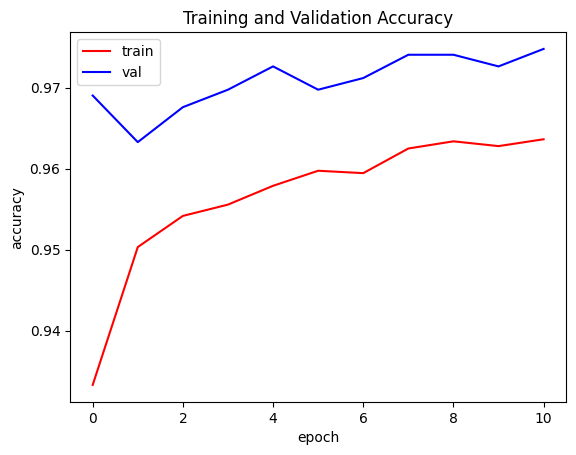

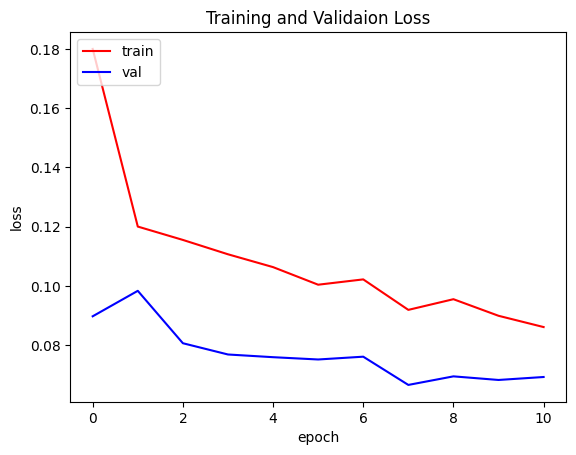

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

## Konversi Model

In [22]:
# ===== Simpan model dalam format Keras =====
model.save("mobilenetv2_seq_catdog.keras")

# ===== Simpan model dalam format SavedModel =====
model.export("mobilenetv2_seq_catdog_savedmodel")

# ===== Konversi ke TFLite =====
converter = tf.lite.TFLiteConverter.from_saved_model("mobilenetv2_seq_catdog_savedmodel")
tflite_model = converter.convert()
with open("mobilenetv2_seq_catdog.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at 'mobilenetv2_seq_catdog_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139762902922064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139762902924944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139762902923792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139762902924560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139762902923600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139762902922256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139762902924176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139762902923984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139762902924368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139762902924752: TensorSpec(shape=(), dtype=tf.resource, name=N

In [23]:
!tensorflowjs_converter --input_format=tf_saved_model mobilenetv2_seq_catdog_savedmodel mobilenetv2_seq_catdog_tfjs


2025-10-22 17:30:02.995973: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761154203.028080   17511 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761154203.038265   17511 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761154203.063705   17511 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761154203.063739   17511 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761154203.063750   17511 computation_placer.cc:177] computation placer alr

In [37]:
shutil.make_archive('mobilenetv2_seq_catdog_savedmodel', 'zip', 'mobilenetv2_seq_catdog_savedmodel')

shutil.make_archive('mobilenetv2_seq_catdog_tfjs', 'zip', 'mobilenetv2_seq_catdog_tfjs')


'/content/mobilenetv2_seq_catdog_tfjs.zip'

In [39]:

files.download('mobilenetv2_seq_catdog_savedmodel.zip')
files.download('mobilenetv2_seq_catdog_tfjs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference (Optional)

In [33]:
model_path = "/content/mobilenetv2_seq_catdog_savedmodel"
model = tf.keras.layers.TFSMLayer(model_path, call_endpoint='serving_default')

img_path = "gambar_kucing.jpg"
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

output = model(img_array)
print(output)

predictions = list(output.values())[0].numpy()

confidence = float(np.max(predictions))
class_index = int(np.argmax(predictions))
classes = ["Cat", "Dog"]
print(f"Prediction: {classes[class_index]} {confidence*100:.2f}%")

{'output_0': <tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.00827131]], dtype=float32)>}
Prediction: Cat 0.83%


# **Membuat File Requirment**

In [40]:
pip freeze > requirements.txt